# Project 8 -- Niharika Rai 

**TA Help:** (for instance) John Smith, Alice Jones, etc., list names of any TAs who helped you

- For example: Help with figuring out how to write a function (describe the tasks that they helped you with)

**Collaboration:** My Friend in CS, My Uncle, Another Student, etc., list names of any other people who helped you

(describe the tasks that they helped you with)
- For example: helped figuring out how to load the dataset.
- Another example: helped debug error with my plot.

**Internet Resources:** Stack Exchange, Stack Overflow, etc.

(describe any information that you learned from internet resources, including the URLs)
- data frames in Pandas versus R from StackOverflow  https://stackoverflow.com/questions/8991709/why-were-pandas-merges-in-python-faster-than-data-table-merges-in-r-in-2012

**ChatGPT, Gemini, Claude, etc:** Any language models or generative AI chatbots that helped you.

(if you used any such tools, please tell us here)
- For example:  I asked ChatGPT how to define a new data frames
- Another example:  Gemini told me how to make a function for sorting my data

- ***Link to AI Chat History***: Please share a link to your chat if you used AI (ex. ChatGPT Shared Links). Link to AI Chat History: https://chatgpt.com/share/69b9f2a2-c164-800d-ae46-910fc94da301 
**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def objective_function(x):
    """
    A simple 1D function to minimize.

    Example: x^2 + 3x + 2 is a simple quadratic function with a minimum at x = -1.5.
    """
    return  x**2 + 3*x + 2 # I put my own function here as requested by the question. 

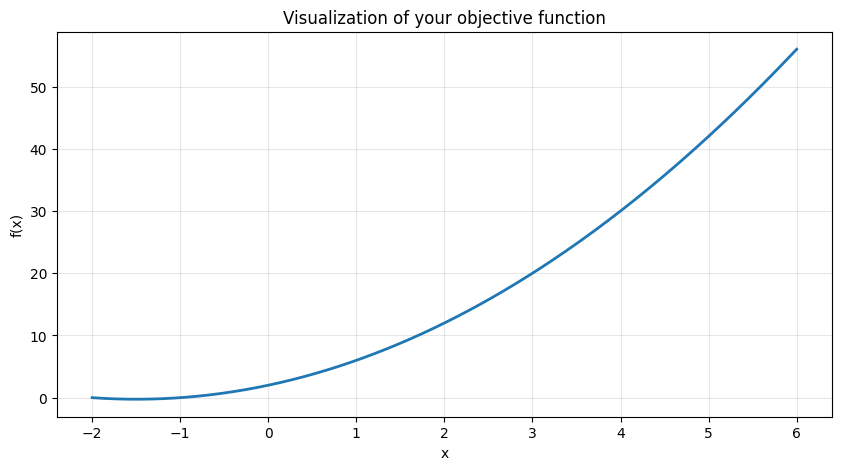

In [2]:
x_vals = np.linspace(-2, 6, 300)
y_vals = objective_function(x_vals)

plt.figure(figsize=(10,5))
plt.plot(x_vals, y_vals, linewidth=2)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Visualization of your objective function")
plt.grid(alpha=0.3)
plt.show()

In [3]:
initial_guess = 0.0  # You can change this
result = minimize(objective_function, initial_guess, method="BFGS")

print(f"Minimum value: {result.fun:.6f}")
print(f"At x = {result.x[0]:.6f}")
print(f"Success? {result.success}")

if not result.success:
    print("Message:", result.message)

Minimum value: -0.250000
At x = -1.500000
Success? True


In [4]:
initial_guess = 3.0  # You can change this
result = minimize(objective_function, initial_guess, method="BFGS")

print(f"Minimum value: {result.fun:.6f}")
print(f"At x = {result.x[0]:.6f}")
print(f"Success? {result.success}")

if not result.success:
    print("Message:", result.message)

Minimum value: -0.250000
At x = -1.500000
Success? True


1.1 I defined a 1D objective function. I created my own function which was: x^2 + 3x + 2. 

1.2 I plotted my function and built intuition about its minimum. From its graph, I could tell that the minimum occurred at x = -1.5 and y = 0. 

1.3 I used SciPy’s optimizer with BFGS to find the minimum. I used the sample code from the question to achieve this. 

1.4 SciPy’s optimizer gives the minimum value as -0.250000 and the x value as -1.500000. This numerical result is similar to what I saw in the plot. The only difference was that I felt the y = 0 but the optimizer gave me a precise value of -0.250000 which was difficult to observe from the plot. 

1.5 Overall, the minimum value and location matches what I saw in the plot. This means that both SciPy’s optimizer and the plot lead to the same answers to the 1D objective function. 

1.6 I changed the initial guess values to different numbers to see what happens but output remains the same. I think that the initial guess allows you to have a decent first guess at the minimum. This helps the optimizer find the minimum, and for complex problems it helps to improve the speed and reliability of the solution. Since my objective function was relatively simple, despite changing the initial guess, my ouput remained the same and is consistent with what the plotted graph shows. 

## Question 2

In [5]:
def constrained_objective(x):
    return  x[0]**2 + 3*x[0] + 2 # define a 1D objective using x[0]

In [6]:
# Example: constraints for 0 <= x <= 5
constraints = [
    {"type": "ineq", "fun": lambda x: x[0]},       # x >= 0
    {"type": "ineq", "fun": lambda x: 5 - x[0]},  # x <= 5
]

In [7]:
initial_guess = [1.0]  # try a value inside the feasible region
result = minimize(constrained_objective, initial_guess, method="SLSQP", constraints=constraints)

print(f"Optimal x = {result.x[0]:.6f}")
print(f"Objective = {result.fun:.6f}")
print("Constraint values at optimum:")
for c in constraints:
    print(" ", c["fun"](result.x))

if not result.success:
    print("Message:", result.message)

Optimal x = -0.000000
Objective = 2.000000
Constraint values at optimum:
  -8.881784197001252e-16
  5.000000000000001


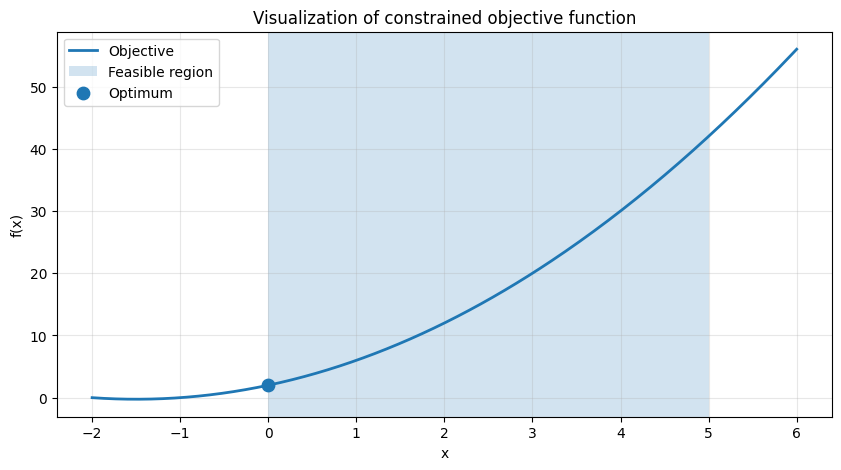

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x_vals = np.linspace(-2, 6, 300)
y_vals = objective_function(x_vals)

plt.figure(figsize=(10,5))

# Plot function
plt.plot(x_vals, y_vals, linewidth=2, label="Objective")

# Feasible region shading (0 ≤ x ≤ 5)
plt.axvspan(0, 5, alpha=0.2, label="Feasible region")

# Optimum point
x_opt = result.x[0]
y_opt = result.fun
plt.scatter(x_opt, y_opt, s=80, zorder=5, label="Optimum")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Visualization of constrained objective function")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

2.1 I defined a constrained objective using the sample code given in the question. However, I modified it to use the same function that I created in question 1. 

2.2 I decided to use the same two constraints given in the question because it suited my objective function well. 

2.3 I used SciPy’s optimizer with constraints and used the sample code given in the question to achieve this.

2.4 I printed and plotted the solution. I faced some errors in the plotting so I used ChatGPT to debug my code. The plot shows the objective function with the shaded feasible region, as marked by the constraints, and the new minimum point. 

2.5 The contraints shift the minimum to a point that is within the feasible region of the objective function. Now, it only looks at the feasible region, defined by our contraints, and chooses the minimum point from this feasible region, given our defined objective function. Hence, the new minimum occurs at x = -8.881784197001252e-16 (very close to 0 as seen in the plot) and y = 5.000000000000001 (half-way between 0 and 10, so about 5 as seen in the plot). 

2.6 Since our constraints says that x shoud be between 0 and 5, and the uncontrained minimum occured at (-1.25, -0.25), so yes, the unconstrained minimum, in this scenario, is outside feasible region, making it infeasible. However, this does not always have to be the case especially when our defined constraints contain the x value at which the absolute minimum occurs. But given our defined objective function and constraints, the original uncontrained minimum value at x = -1.25 is clearly outside the contrained values (0<=x<=5).  

## Question 3

In [9]:
def neg_profit(x):
    # x = [units of A, units of B]
    return -(10*x[0] + 15*x[1])  # return negative total profit

In [10]:
constraints = [
    {"type": "ineq", "fun": lambda x: 100 - (2*x[0] + x[1])},    # labor constraint (ineq)
    {"type": "ineq", "fun": lambda x: 120 - (x[0] + 3*x[1])},    # material constraint (ineq) 
    {"type": "ineq", "fun": lambda x: x[0]},                     # non-negativity for product A             
    {"type": "ineq", "fun": lambda x: x[1]},                     # non-negativity for product B          
]

In [11]:
initial_guess = [10, 10]  # a feasible guess, feel free to change this
result = minimize(neg_profit, initial_guess, method="SLSQP", constraints=constraints)

A_opt, B_opt = result.x
max_profit = -result.fun  # take the negative of the result.fun, as we minimized negative profit, so the maximum is the negative of that value

print("Optimization successful?", result.success)
print(f"Units of Product A: {A_opt:.4f}")
print(f"Units of Product B: {B_opt:.4f}")
print(f"Maximum profit: ${max_profit:.2f}")

# Print resource usage
labor_used = 2*result.x[0] + 1*result.x[1]
material_used = 1*result.x[0] + 3*result.x[1]
print(f"Labor used: {labor_used:.2f} / 100")
print(f"Material used: {material_used:.2f} / 120")

Optimization successful? True
Units of Product A: 36.0000
Units of Product B: 28.0000
Maximum profit: $780.00
Labor used: 100.00 / 100
Material used: 120.00 / 120


In [12]:
# Verify constraints at the optimum. 
for c in constraints:
    print(c["fun"](result.x))

-2.9690738756471546e-10
-3.6860114960290957e-10
36.00000000010442
28.00000000008806


3.1 I defined the negative profit objective function. I was initially confused about the logic on how to use just one x variable to define the profits for two products, so I used ChatGPT for assistance. I found that x[0] represents Product A and x[1] represents Product B and the values multiplied to these were the per unit profit generated by each of the products. 

3.2 I add all resource constraints. I used the sample codes from the previous questions to formulate the constraints and ChatGPT helped me verify that what I wrote followed the correct logic.  

3.3 I ran the optimizer and printed the optimal plan. I used the sample code from the question and filled up some of the gaps with the comment hints and formulas. I was confused about how to calculate the labor and material used so I used ChatGT and found that these were the same formulas that I used when writing the contraints. The only difference was that now I was multiplying the coefficients by the optimal units for both products A and B. 

3.4 From the printed optimal plan, we can see that all of the labor and material are used. Then, I also verified the constraints at the optimum and found that the values result in the optimal units for products A and B. This means that all our constraints are fully satisfied.  

3.5 We minimized the negative profit because SciPy’s optimizer only minimizes and does not maximize the objective function. Hence, to maximize a function, we must minimize the negative of that function. For example, we created a negative profit function and minimizing this negative profit function would help us maximize the actual profit function and get the maximum profit value.  

3.6 If we removed the non-negativity constraints, then it is possible that we could get values that do not make sense in the context of this problem. For example, the units of products A and B have to be a positive number and the lowest it can be is 0, given that we are calculating profit and profit depends on the units sold. Without the non-negativity constraint, we are allowing the SciPy’s optimizer to choose values where x could be less than 0, leading to negative units of products A and B, which does not make sense if you are calculating profit. Hence, non-negativity constraints are imposed to help the Scipy's optimizer find us reasonable values given the context of this problem. 

## Question 4

In [13]:
def objective2d(v):
    x, y = v[0], v[1]
    return (x-1)**2 + (y-2)**2 # TODO: a smooth 2D function with a clear minimum, e.g. (1, 2): f = (x-1)^2 + (y-2)^2

In [14]:
initial_guess = [1, 1]
result = minimize(objective2d, initial_guess, method="BFGS")

print(f"Optimal x = {result.x[0]:.6f}, y = {result.x[1]:.6f}")
print(f"Optimal value = {result.fun:.6f}")

Optimal x = 1.000000, y = 2.000000
Optimal value = 0.000000


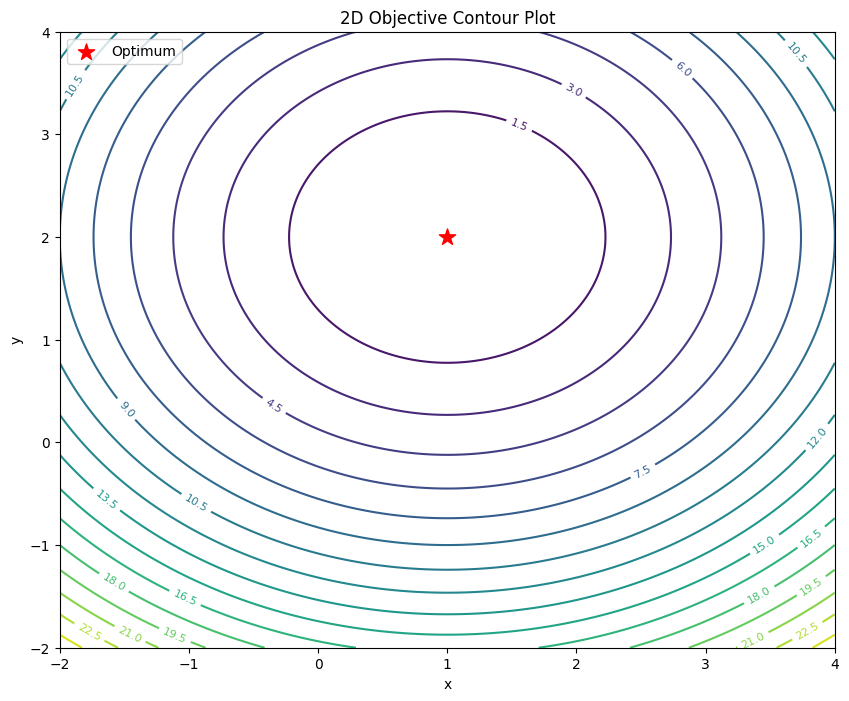

In [15]:
# Build grid
x = np.linspace(-2, 4, 200)
y = np.linspace(-2, 4, 200)
X, Y = np.meshgrid(x, y)

Z = objective2d([X, Y])

plt.figure(figsize=(10,8))
cs = plt.contour(X, Y, Z, levels=20)
plt.clabel(cs, inline=True, fontsize=8)
plt.scatter(result.x[0], result.x[1], color="red", s=150, marker="*", label="Optimum")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Objective Contour Plot")
plt.legend()
plt.show()

4.1 I defined a 2D objective function using the sample code given in the question. I used the same objective function given in the hinted comments of the sample code. ChatGPT helped me debug my code as I had not written the function in the corect expected syntax. 

4.2 I solved the 2D objective function with SciPy using the sample code given in the question. 

4.3 I created a contour plot and marked the optimum using the sample code given in the question. I was initially getting errors when executing the code because I ran the visualization code cell before running the optimizer. I corrected this minor error with ChatGPT's help. 

4.4 My 2D function was (x-1)^2 + (y-2)^2 which has a clear minimum occuring at (1, 2). On running the Scipy's optimizer, I get the same result where the optimal x = 1 and optimal y = 2. As a result, the optimal value is (1-1)^ + (2-2)^ = 0. The optimal values of x and y are marked and shown in the contour plot.

4.5 The contour plot shows that the minimum occurs at x = 1 and y = 2. This point is marked by the red star and is placed exactly in the center of the plot. Hence, when you input these x and y values into the 2D objective function, you get an optimal minimum value of 0. Hence, for all the bigger sized ovals in the plot, that follow the same pattern of the 2D objective function, the optimal x and y values remain the same.   

4.6 Yes, the optimizer’s solution matches the contour intuition. 

## Question 5

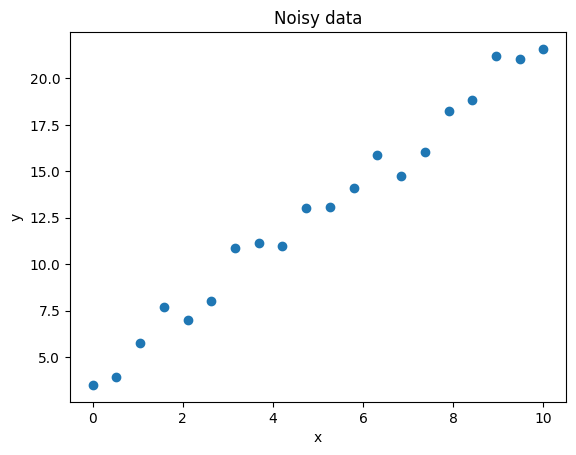

In [16]:
real_a = 2 # define some real value for a
real_b = 3 # define some real value for b
np.random.seed(42)
x_data = np.linspace(0, 10, 20)
y_true = real_a * x_data + real_b
y_data = y_true + np.random.normal(0, 1, len(x_data))

plt.scatter(x_data, y_data)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy data")
plt.show()

In [17]:
def model(params, x):
    a, b = params[0], params[1]
    return a * x + b

def sse(params):
    a, b = params
    y_pred = a * x_data + b # From our input params and x_data, calculate the predicted y values
    return np.sum((y_data - y_pred)**2)# return the SSE

In [18]:
initial_guess = [5, 6] # make an initial guess for a and b, that is different from your real_a and real_b
result = minimize(sse, initial_guess, method="BFGS") # run the optimizer with minimize

a_opt, b_opt = result.x
print(f"Estimated a = {a_opt:.4f}, b = {b_opt:.4f}")
print(f"SSE = {result.fun:.4f}")

Estimated a = 1.8108, b = 3.7746
SSE = 10.9192


In [19]:
initial_guess = [4, 5] # make an initial guess for a and b, that is different from your real_a and real_b
result = minimize(sse, initial_guess, method="BFGS") # run the optimizer with minimize

a_opt, b_opt = result.x
print(f"Estimated a = {a_opt:.4f}, b = {b_opt:.4f}")
print(f"SSE = {result.fun:.4f}")

Estimated a = 1.8108, b = 3.7746
SSE = 10.9192


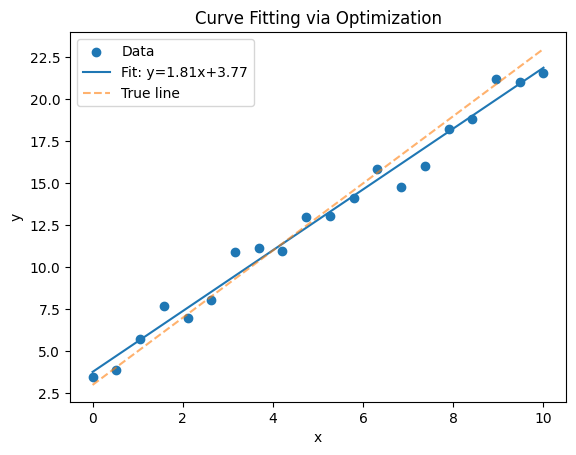

In [20]:
x_plot = np.linspace(0, 10, 100)

plt.scatter(x_data, y_data, label="Data")

# Fitted line
plt.plot(x_plot, model([a_opt, b_opt], x_plot),
         label=f"Fit: y={a_opt:.2f}x+{b_opt:.2f}")

# True line
y_true_plot = model([real_a, real_b], x_plot)
plt.plot(x_plot, y_true_plot,
         linestyle="--", alpha=0.6, label="True line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Curve Fitting via Optimization")
plt.legend()
plt.show()

5.1 I estimated the parameters by minimizing SSE using the sample codes given in the question. For this, I had to define a real value for 'a' and 'b', write the sse function, make an initial guess and run the optimizer with minimize. 

5.2 I plotted the fitted model on top of the data using the sample code given in the question. However, I was getting errors when running the code and used ChatGPT to debug the sample code. I found that there was a shape mismathc error so I corrected the code by recomputing y_true_plot for the new x_plot (that has a length of 100 for a smoother plot). 

5.3 After I found the optimized values for 'a' and 'b', I used these coefficients on the x_data to calculate the predicted y-values, connect them with a line to plot the regression line (blue line in the plot above). The true line was plotted using the defined real values of 'a' and 'b' instead. Hence, the true line is represented by the orange line in the plot. It is slighly different from the regression line. 

5.4 The optimizer’s solution are very close to the true values. For example, the real value that I defined for 'a' was 2 and the optimizer's estimated value for 'a' was 1.8108, which is very close to 2. Then, the real value that I defined for 'b' was 3 and the optimizer's estimated value for 'b' was 3.7746 which is a little over 3 but less than 4. Although the optimizer does not accurately find the true values, it does a relatively good job in estimating them. I tried changing the initial guess from [5, 6] to [4, 5] and my output remained the same. But otherwise, changing the initial guess usually helps the optimizer find the minimum, and for complex problems it helps to improve the speed and reliability of the solution. 

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
